<a href="https://colab.research.google.com/github/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/blob/main/MariaCopia_de_indexH1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:

!wget https://github.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/raw/main/PeruMaps.gpkg

--2026-07-14 18:32:23--  https://github.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/raw/main/PeruMaps.gpkg
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/main/PeruMaps.gpkg [following]
--2026-07-14 18:32:23--  https://raw.githubusercontent.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/main/PeruMaps.gpkg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60784640 (58M) [application/octet-stream]
Saving to: ‘PeruMaps.gpkg’

PeruMaps.gpkg       100%[===================>]  57.97M   183MB/s    in 0.3s    

2026-07-

In [8]:
import geopandas as gpd

peru = gpd.read_file("PeruMaps.gpkg")

peru.head()


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'PeruMaps.gpkg': 'distritos' (default), 'good_geom'. Specify layer parameter to avoid this warning.
  result = read_func(


,DEPARTAMEN,PROVINCIA,DISTRITO,Ubigeo,Poblacion,Superficie,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
0,TACNA,TACNA,CORONEL GREGORIO ALBARRACIN LANCHIPA,230110,123662,187.74,0.578968,71.178389,15.8,0.8,"MULTIPOLYGON (((-70.17413 -18.12896, -70.17461..."
1,TACNA,TACNA,POCOLLAY,230108,22319,265.65,0.645954,75.825743,16.1,0.9,"MULTIPOLYGON (((-69.93475 -17.92557, -69.90467..."
2,TACNA,TACNA,CALANA,230103,3338,108.38,0.564102,77.829717,15.9,3.3,"MULTIPOLYGON (((-70.11604 -17.91106, -70.11457..."
3,TACNA,TACNA,TACNA,230101,80845,1877.78,0.696613,75.491958,7.4,0.6,"MULTIPOLYGON (((-70.3149 -17.94498, -70.30682 ..."
4,TACNA,TACNA,SAMA,230109,2679,1115.98,0.552622,70.500250,52.4,10.8,"MULTIPOLYGON (((-70.42497 -17.88934, -70.48022..."


In [59]:
#1. Install and activate libraries needed
!pip install geopandas libpysal esda mapclassify contextily

# Import libraries
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Libraries for spatial weights and LISA analysis
from libpysal.weights import Queen, KNN
from esda.moran import Moran_Local

# Library for mapping categories
import mapclassify

In [9]:
LinkPeru="https://github.com/MariaReyesMedina/DACSS690C_Computation_SocialSci_Methods/raw/main/PeruMaps.gpkg"
peru=gpd.read_file(LinkPeru,layer='good_geom')
# basic description
peru.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1873 entries, 0 to 1872
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   DEPARTAMENTO              1873 non-null   object  
 1   PROVINCIA                 1873 non-null   object  
 2   DISTRITO                  1873 non-null   object  
 3   ubigeo                    1873 non-null   object  
 4   Poblacion                 1873 non-null   int64   
 5   IDH2019                   1873 non-null   float64 
 6   Educ_sec_comp2019_pct     1873 non-null   float64 
 7   NBI2017_pct               1873 non-null   float64 
 8   Viv_sin_serv_hig2017_pct  1873 non-null   float64 
 9   geometry                  1873 non-null   geometry
dtypes: float64(4), geometry(1), int64(1), object(4)
memory usage: 146.5+ KB


1. Install and activate libraries needed.

In [53]:

!pip show pysal pandas geopandas libpysal esda


import geopandas as gpd
from libpysal.graph import Graph
import pandas as pd
import esda # from pysal


import matplotlib.pyplot as plt

#Sanitycheck**


Name: pysal
Version: 25.7
Summary: Meta Package for PySAL - A library of spatial analysis functions
Home-page: 
Author: 
Author-email: Serge Rey <sjsrey@gmail.com>, Levi Wolf <levi.john.wolf@gmail.com>
License: BSD 3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: access, beautifulsoup4, esda, geopandas, giddy, inequality, libpysal, mapclassify, mgwr, momepy, numpy, packaging, pandas, platformdirs, pointpats, requests, scikit-learn, scipy, segregation, shapely, spaghetti, spglm, spint, splot, spopt, spreg, tobler
Required-by: 
---
Name: pandas
Version: 2.2.2
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution 

2. Read the map of Peru (same layer used in class)

<Axes: >

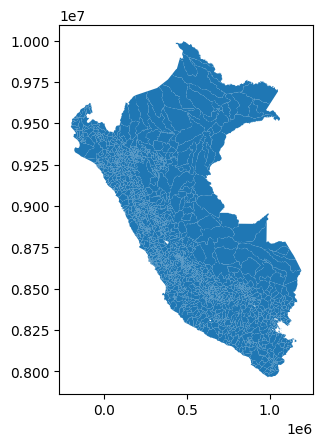

In [36]:
peru=peru.to_crs(5387)
peru.plot()

3. Keep the DEPARTAMENTO of 'LIMA'.

In [65]:
lima=peru[peru['DEPARTAMENTO']=='Lima']
lima.head()

,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
39,Lima,YAUYOS,ALIS,PE151002,1233,0.646897,69.474298,30.3,6.6,"MULTIPOLYGON (((415396.076 8647591.116, 415450..."
40,Lima,YAUYOS,AYAUCA,PE151003,2293,0.544152,43.167400,61.9,57.2,"MULTIPOLYGON (((389530.693 8626520.884, 389743..."
54,Lima,HUAURA,AMBAR,PE150802,2761,0.316448,42.060097,73.3,60.2,"MULTIPOLYGON (((243293.978 8826436.11, 243328...."
65,Lima,LIMA,ANCON,PE150102,42124,0.668889,72.117976,21.7,1.1,"MULTIPOLYGON (((281417 8715329, 281397.439 871..."
71,Lima,OYON,ANDAJES,PE150902,1058,0.488913,71.684369,36.4,28.5,"MULTIPOLYGON (((291522.945 8820149.937, 291499..."


4. Produce the LISA MAP using the normalized neighborhood  matrix (or weights matrix) using the QUEEN criterion

In [66]:
# Create spatial weights matrix using the QUEEN criterion
# Queen considers polygons neighbors when they share an edge or a corner
w_queen = Queen.from_dataframe(
    lima,
    use_index=True
)

# Normalize the weights matrix (row-standardization)
w_queen.transform = "R"


# Calculate Local Moran's I (LISA)
# Using the centroid latitude as the variable for spatial autocorrelation
lisa_queen = Moran_Local(
    lima.geometry.centroid.y,
    w_queen
)


# Save LISA statistics into new columns
lima.loc[:, "Lisa_I_queen"] = lisa_queen.Is
lima.loc[:, "p_value_queen"] = lisa_queen.p_sim

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [67]:
# Create LISA cluster categories based on Local Moran results
# 1 = High-High, 2 = Low-High, 3 = Low-Low, 4 = High-Low

lima["Lisa_queen"] = lisa_queen.q

# Rename numeric categories with meaningful labels
lima["Lisa_queen"] = lima["Lisa_queen"].replace({
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
})

# Check categories
lima["Lisa_queen"].value_counts()

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,count
Lisa_queen,
Low-Low,104
High-High,66
Low-High,1


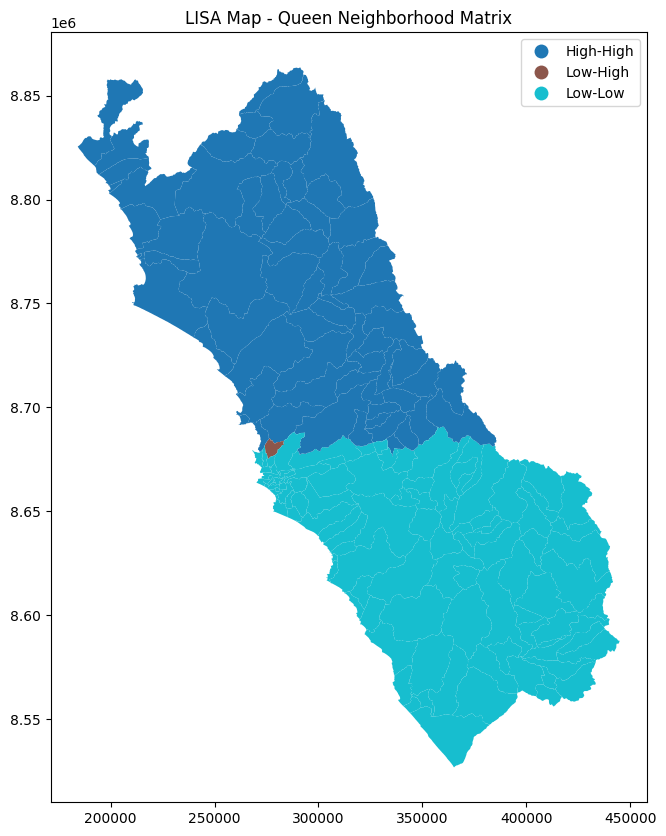

In [68]:
# Plot the LISA map using Queen neighbors

lima.plot(
    column="Lisa_queen",
    categorical=True,
    legend=True,
    figsize=(10,10)
)

# Add title
plt.title("LISA Map - Queen Neighborhood Matrix")
plt.show()

In [69]:
# Create K-nearest neighbors spatial weights matrix
# Each district will have 8 closest neighbors
w_knn8 = KNN.from_dataframe(
    lima,
    k=8
)

# Normalize weights
w_knn8.transform = "R"


# Calculate Local Moran's I using KNN weights

lisa_knn8 = Moran_Local(
    lima.geometry.centroid.y,
    w_knn8
)


# Save LISA results
lima["Lisa_I_knn8"] = lisa_knn8.Is
lima["p_value_knn8"] = lisa_knn8.p_sim

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [70]:
# Save KNN LISA categories

lima["Lisa_knn8"] = lisa_knn8.q


# Rename categories

lima["Lisa_knn8"] = lima["Lisa_knn8"].replace({
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
})


# Check results

lima["Lisa_knn8"].value_counts()

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,count
Lisa_knn8,
Low-Low,103
High-High,65
Low-High,2
High-Low,1


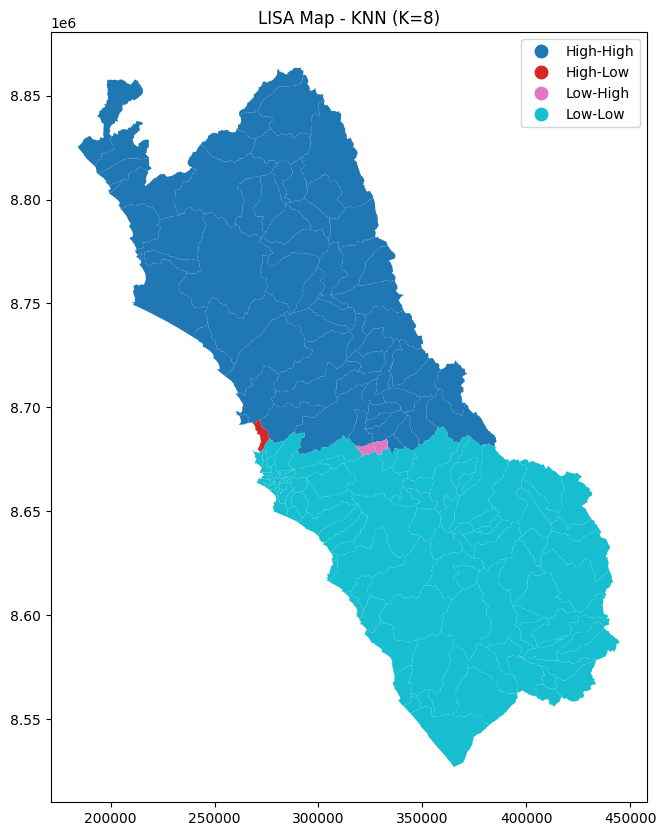

In [71]:
# Plot the LISA map using KNN=8 neighbors

lima.plot(
    column="Lisa_knn8",
    categorical=True,
    legend=True,
    figsize=(10,10)
)

plt.title("LISA Map - KNN (K=8)")
plt.show()

In [72]:
# Compare if districts changed LISA category between Queen and KNN

comparison = lima[
    ["Lisa_queen", "Lisa_knn8"]
].copy()


# Identify districts where categories are different

different = lima[
    lima["Lisa_queen"] != lima["Lisa_knn8"]
]


# Display districts with different classifications

different[
    ["DEPARTAMENTO", "PROVINCIA", "DISTRITO", "Lisa_queen", "Lisa_knn8"]
]

,DEPARTAMENTO,PROVINCIA,DISTRITO,Lisa_queen,Lisa_knn8
431,Lima,LIMA,COMAS,Low-High,Low-Low
1248,Lima,LIMA,PUENTE PIEDRA,High-High,High-Low
1316,Lima,HUAROCHIRI,RICARDO PALMA,Low-Low,Low-High
1530,Lima,HUAROCHIRI,SANTA CRUZ DE COCACHACRA,Low-Low,Low-High
